# Capstone — When does physics emerge in CaloDiffusion?

**Read `START_HERE.md` first** (the idea) and skim `JUMPING_OFF_POINTS.md` (the plan &
deliverables). This notebook gets you to **M0** (tools working) and scaffolds the **core**
measurement — the emergence curves and lock-in steps of four observables along the x̂₀
trajectory. The physics (the observables, the lock-in, the interpretation) is left to you as
`TODO`s on purpose.

## 0 · Setup

In [1]:
import sys, os
try:
    import calodiff_probe as cp          # works when run from this folder
except ModuleNotFoundError:              # or from the repo root
    sys.path.insert(0, 'capstone/calodiffusion')
    import calodiff_probe as cp
import numpy as np, torch, matplotlib.pyplot as plt
print('running on:', cp.DEVICE)   # 'cuda' on the GPU box, else 'cpu' (generation is slow on cpu)

running on: cuda


## 1 · Warm-up → **M0** (worked — just run these)

Get the tools in your hands before the real work. Nothing here is graded; it de-risks the API.

### 1a · What a shower looks like
A real shower as a **layer × radius** heatmap (summed over the angular axis).



 Model: 

Event start, stop:  0 16
dset 2


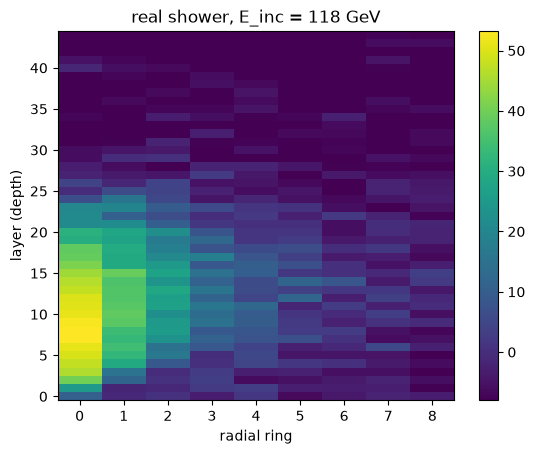

In [2]:
model = cp.load_model('electron')
x, E, E_inc = cp.load_showers('electron', n=16)
grid = cp.regular_grid(model, x)          # (16, layer=45, angular=16, radial=9)
plt.imshow(grid[0].sum(axis=1), aspect='auto', origin='lower')
plt.xlabel('radial ring'); plt.ylabel('layer (depth)')
plt.title(f'real shower, E_inc = {E_inc[0]:.0f} GeV'); plt.colorbar(); plt.show()

### 1b · The forward (noising) process
The model learns to *reverse* this. Watch a shower dissolve into noise.

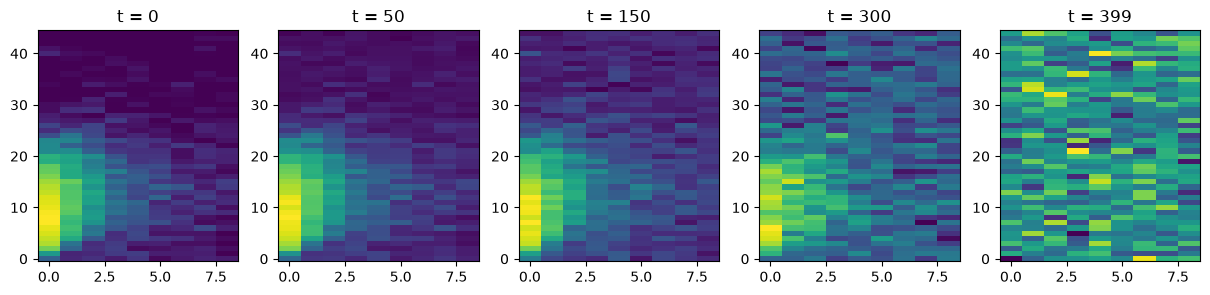

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, t in zip(axes, [0, 50, 150, 300, 399]):
    x_t, _ = cp.noise_at(model, x, t)
    ax.imshow(cp.regular_grid(model, x_t)[0].sum(1), aspect='auto', origin='lower')
    ax.set_title(f't = {t}')
plt.show()

### 1c · Does the model actually denoise?
It predicts the noise added at step `t`; the prediction should correlate with the truth (~0.9).

In [4]:
x_t, eps = cp.noise_at(model, x, t=100)
eps_hat  = cp.predict_noise(model, x_t, E, t=100)
corr = torch.corrcoef(torch.stack([eps_hat.flatten(), eps.flatten()]))[0, 1]
print(f'corr(predicted, true noise) = {corr:.3f}   # ~0.9 = the model works')

corr(predicted, true noise) = 0.908   # ~0.9 = the model works


---
## 2 · The core — emergence curves & lock-in  → **M1 / M2**

As the model builds a shower from noise, it produces at every step a running guess of the
finished shower: **x̂₀** (START_HERE §2). We compute physics on x̂₀ **in physical units** at
each step and ask: *in what order do the observables settle?*

### 2a · Get the x̂₀ trajectory (worked)
⚠️ Generation is slow on CPU — keep `n` small here; move to the **GPU** for real runs.
`x0s` is the per-step list of x̂₀ frames (index 0 = noisiest ... last = clean).

In [5]:
n = 8
E_inc_gev = [50.] * n                     # fixed energy for the core measurement
E_cond = cp.encode_energy('electron', E_inc_gev)
x_final, xs, x0s = cp.sample(model, E_cond, debug=True)
print(f'{len(x0s)} trajectory frames, each {np.asarray(x0s[0]).shape}')
# convert one frame to a physical GeV grid to see the shape you'll work with:
print('one frame -> physical grid:', cp.to_physical_grid(model, x0s[-1], E_inc_gev).shape,
      '= (n, layer, angular, radial)')

SAMPLE ALGO : ddpm
Time for sampling 8 events is 5.185626029968262 seconds
398 trajectory frames, each (8, 1, 45, 16, 9)
dset 2
one frame -> physical grid: (8, 45, 16, 9) = (n, layer, angular, radial)


### Physical grid: use `to_physical_grid` (not `regular_grid`) for observables

`to_physical_grid` gives **real deposited energy on a regular (layer, angular, radial)
grid** — non-negative and energy-conserving — for *every* particle. For photon/pion it
rebins the irregular geometry correctly; for electron it's already regular. Compute all
your observables on this. **Don't** use `regular_grid` for physics: that runs the trained
GLaM encoder (meant for model-space tensors) and on physical values it returns negative,
non-conserving numbers. Because `to_physical_grid` handles the geometry, *the same
observable code works unchanged for all three particles.*

In [6]:
for particle in ['electron', 'photon']:
    mp = cp.load_model(particle)
    xp, Ep, Einc_p = cp.load_showers(particle, n=8)
    g_phys = cp.to_physical_grid(mp, xp, Einc_p.cpu().numpy())    # <- the right tool
    print(f'{particle:9s} grid {g_phys.shape[1:]}  min {g_phys.min():+.3f} GeV  '
          f'total/shower {g_phys.reshape(8,-1).sum(1)[0]:.1f} GeV')



 Model: 

Event start, stop:  0 8
dset 2
dset 2
electron  grid (45, 16, 9)  min +0.000 GeV  total/shower 94.2 GeV


 Model: 

Event start, stop:  0 8
dset 11
dset 11
photon    grid (5, 10, 30)  min +0.000 GeV  total/shower 15.9 GeV


### 2b · The four observables  ⟵ **your job**
Each takes a physical grid `g` of shape `(N, layer, angular, radial)` and returns one number
**per shower** (an array of length N). One is done as the pattern; write the other three.

- `total_energy` — sum of all cell energies *(worked, shows the pattern)*
- `depth` — energy-weighted **mean layer index** (how deep the shower peaks)
- `radial_spread` — energy-weighted **RMS radius** (how wide it is)
- `occupancy` — fraction of cells above a **fixed** threshold `ecut` *(use `model.config['ECUT']`)*

In [7]:
def total_energy(g):                       # (N, layer, ang, rad) -> (N,)
    return g.sum(axis=(1, 2, 3))

def depth(g):
    E = g.sum(axis=(2, 3))          
    layers = np.arange(E.shape[1])
    total_E = E.sum(axis=1)
    mean_depth = (E * layers).sum(axis=1) / total_E
    return mean_depth

def radial_spread(g):
    radial_energy = g.sum(axis=(1,2))
    r = np.arange(g.shape[3])
    total_energy = radial_energy.sum(axis=1)
    mean_r = (radial_energy * r).sum(axis=1) / total_energy
    r_diff_sq = (r[np.newaxis, :] - mean_r[:, np.newaxis])**2
    var = (r_diff_sq * radial_energy).sum(axis=1) / total_energy
    return np.sqrt(var)

def occupancy(g, ecut):
    # TODO: fraction of cells with energy > ecut (a number per shower).
    occupied = g > ecut
    occupied_cells = occupied.sum(axis=(1, 2, 3))
    total_cells = g.shape[1] * g.shape[2] * g.shape[3]
    return occupied_cells / total_cells

### 2c · Build the emergence curves  ⟵ **your job**
Walk the trajectory, compute each observable on x̂₀ (physical units) at every step, and
**normalise each curve to its final value** (the last frame). Then plot all four vs step.

*Expectation to test:* total energy & depth settle **early** (coarse), radial spread &
occupancy **late** (fine). Is that what you see?



 Model: 

Event start, stop:  0 8
dset 2
SAMPLE ALGO : ddpm
Time for sampling 16 events is 6.270442485809326 seconds
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2

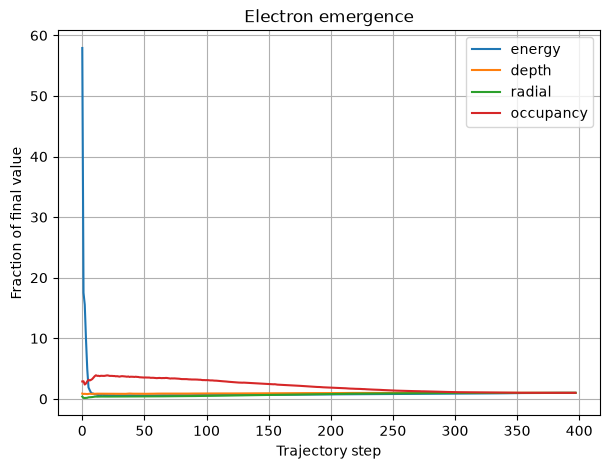



 Model: 

Event start, stop:  0 8
dset 11
SAMPLE ALGO : ddpm
Time for sampling 16 events is 5.245709419250488 seconds
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11
dset 11


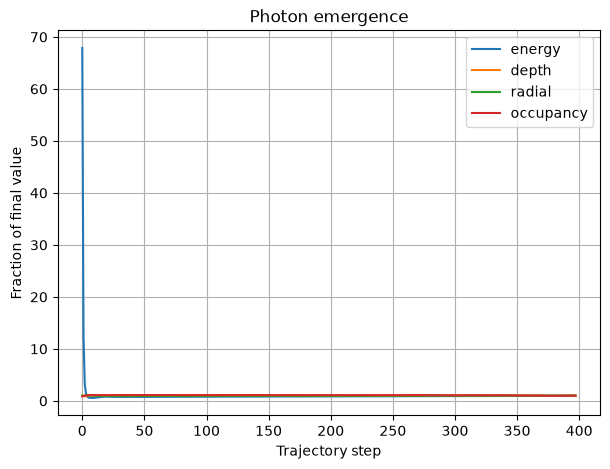



 Model: 

Event start, stop:  0 8
dset 10
SAMPLE ALGO : ddpm
Time for sampling 16 events is 5.471842288970947 seconds
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10
dset 10


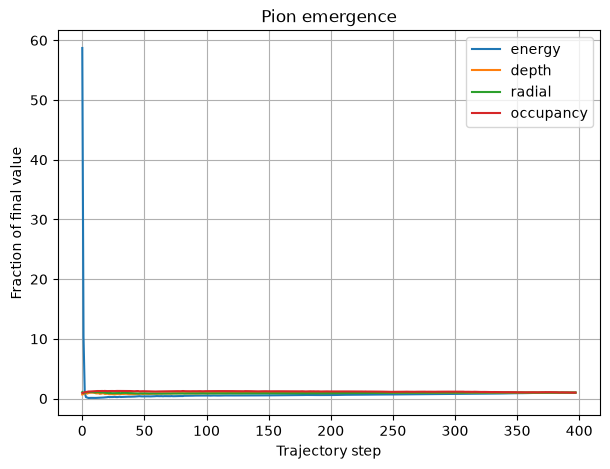

In [25]:
particles = ['electron', 'photon', 'pion']

n = 16
all_curves = {}

for particle in particles:

    # 1. Load model
    model = cp.load_model(particle)

    # 2. Load showers
    x, E, E_inc = cp.load_showers(particle, n=8)

    # 3. Generate trajectory
    E_inc_gev = [50.] * n
    E_cond = cp.encode_energy(particle, E_inc_gev)
    x_final, xs, x0s = cp.sample(model, E_cond, debug=True)

    ecut = model.config['ECUT']

    obs_fns = {
        'energy': total_energy,
        'depth': depth,
        'radial': radial_spread,
        'occupancy': lambda g: occupancy(g, ecut)
    }

    # Create empty dictionary
    curves = {name: [] for name in obs_fns}

    # Compute the curves
    for x0 in x0s:
        g = cp.to_physical_grid(model, x0, E_inc_gev)

        for name, fn in obs_fns.items():
            curves[name].append(np.median(fn(g)))

    #  Save the curves AFTER they have been computed
    all_curves[particle] = curves

    # Plot
    plt.figure(figsize=(7,5))

    for name, vals in curves.items():
        vals = np.array(vals) / vals[-1]
        plt.plot(vals, label=name)

    plt.title(f"{particle.capitalize()} emergence")
    plt.xlabel("Trajectory step")
    plt.ylabel("Fraction of final value")
    plt.grid()
    plt.legend()
    plt.show()

### 2d · The lock-in step + table  ⟵ **your job**
Define the **lock-in step** of an observable = the first step after which its (normalised)
curve stays within ~10% of its final value. Compute it for all four and make a small table.

*This scalar is the result* — it turns 'look at this plot' into a number you can compare
across particles (the nice-to-have).

In [9]:
def lock_in_step(norm_curve, tol=0.1):
    norm_curve = np.array(norm_curve)
    out_of_tol = np.abs(norm_curve - 1) > tol
    out_indices = np.where(out_of_tol)[0]
    if len(out_indices) == 0 :
        return 0
    lock_step = out_indices[-1] + 1
    return min(lock_step , len(norm_curve) - 1)

print(f"{'Observable':<15} | {'Lock-in Step':<12}")
print("-" * 30)
lock_in_results = {}
for name, vals in curves.items():
    # Re-normalize the curve to its final value
    norm_curve = np.array(vals) / vals[-1]
    # Calculate the lock-in step using the default 10% (0.1) tolerance
    step = lock_in_step(norm_curve, tol=0.1)
    lock_in_results[name] = step
    print(f"{name:<15} | {step:<12}")
        

Observable      | Lock-in Step
------------------------------
energy          | 303         
depth           | 102         
radial          | 247         
occupancy       | 301         


In [10]:
#--Compare resion--#
# Setup Particles and Constants
particles = ['electron', 'photon', 'pion'] # Adjust based on what your library supports
all_results = {}
n_showers = 8
E_fixed = 50.0  # Constant energy for fair comparison

# original observable functions
def total_energy(g):
    return g.sum(axis=(1, 2, 3))

def depth(g):
    E = g.sum(axis=(2, 3))          
    layers = np.arange(E.shape[1])
    total_E = E.sum(axis=1) + 1e-9 # Prevent div by zero
    return (E * layers).sum(axis=1) / total_E

def radial_spread(g):
    radial_energy = g.sum(axis=(1,2))
    r = np.arange(g.shape[3])
    total_E = radial_energy.sum(axis=1) + 1e-9
    mean_r = (radial_energy * r).sum(axis=1) / total_E
    r_diff_sq = (r[np.newaxis, :] - mean_r[:, np.newaxis])**2
    var = (r_diff_sq * radial_energy).sum(axis=1) / total_E
    return np.sqrt(var)

def occupancy(g, ecut):
    occupied = g > ecut
    return occupied.sum(axis=(1, 2, 3)) / (g.shape[1] * g.shape[2] * g.shape[3])

def lock_in_step(norm_curve, tol=0.1):
    norm_curve = np.array(norm_curve)
    out_of_tol = np.abs(norm_curve - 1) > tol
    out_indices = np.where(out_of_tol)[0]
    return out_indices[-1] + 1 if len(out_indices) > 0 else 0

#The Comparison Loop 
for p_type in particles:
    print(f"Processing {p_type}...")
    
    # Load Model and Data
    model = cp.load_model(p_type)
    ecut = model.config['ECUT']
    
    # Prepare Energy Condition (Fixed for comparison)
    E_inc_gev = np.full(n_showers, E_fixed)
    E_cond = cp.encode_energy(p_type, E_inc_gev)
    
    # Generate Trajectory (x0s) - This is the expensive part
    
    _, _, x0s = cp.sample(model, E_cond, debug=True) 
    
    # Define observable functions for this model
    obs_fns = {
        'energy': total_energy, 
        'depth': depth,
        'radial': radial_spread, 
        'occupancy': lambda g: occupancy(g, ecut)
    }
    
    # Calculate curves for this particle
    p_curves = {name: [] for name in obs_fns}
    for x0 in x0s:
        # Convert noisy frame to physical grid
        g = cp.to_physical_grid(model, x0, E_inc_gev)
        for name, fn in obs_fns.items():
            p_curves[name].append(np.median(fn(g)))
            
    
    # Store normalized results
    all_results[p_type] = {
        name: np.array(vals) / (vals[-1] + 1e-9) 
        for name, vals in p_curves.items()
    }


Processing electron...


 Model: 

SAMPLE ALGO : ddpm
Time for sampling 8 events is 5.179392576217651 seconds
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
d

In [15]:

#  Comparison Table 
obs_names = ['energy', 'depth', 'radial', 'occupancy']
print(f"\n{'Observable':<12} | " + " | ".join([f"{p:<10}" for p in particles]))
print("-" * (15 + 13 * len(particles)))
for obs in obs_names:
    steps = [str(lock_in_step(all_results[p][obs])) for p in particles]
    print(f"{obs:<12} | " + " | ".join([f"{s:<10}" for s in steps]))


Observable   | electron   | photon     | pion      
------------------------------------------------------
energy       | 312        | 275        | 351       
depth        | 107        | 4          | 72        
radial       | 241        | 2          | 183       
occupancy    | 305        | 354        | 394       


---
## 3 · Where to go next

- **Nice-to-have (the headline):** repeat §2 for `'photon'` and `'pion'` at *matched* energies.
  Because you built the loop on `to_physical_grid`, the **same code works unchanged** —
  just swap the particle. Does the coarse→fine gap **widen** for the messy hadronic pion
  showers? → Table 2, Fig 3.
- **Optional (pick one, with us):** spectral emergence (azimuthal FFT, electron only) /
  conditioning intervention / a linear probe inside the U-Net. See `JUMPING_OFF_POINTS.md`.

Deliverables, milestones, and what's *out* of scope are all in `JUMPING_OFF_POINTS.md`.

In [16]:
# New dictionary to store real statistics
all_stats = {}

for p_type in particles:
    print(f"Processing {p_type} for real stats...")
    model = cp.load_model(p_type)
    E_inc_gev = np.full(n_showers, E_fixed)
    E_cond = cp.encode_energy(p_type, E_inc_gev)
    _, _, x0s = cp.sample(model, E_cond, debug=True)
    
    # Initialize storage for this particle
    p_stats = {name: {'mean': [], 'std': []} for name in obs_fns}
    
    for x0 in x0s:
        g = cp.to_physical_grid(model, x0, E_inc_gev)
        for name, fn in obs_fns.items():
            # Calculate values for ALL showers in the batch at this step
            raw_values = fn(g) 
            
            # Save the Real Mean and Real Std Dev
            p_stats[name]['mean'].append(np.mean(raw_values))
            p_stats[name]['std'].append(np.std(raw_values))
    
    # Normalize by the final mean value
    for name in obs_fns:
        final_val = p_stats[name]['mean'][-1] + 1e-9
        p_stats[name]['mean'] = np.array(p_stats[name]['mean']) / final_val
        p_stats[name]['std'] = np.array(p_stats[name]['std']) / final_val
        
    all_stats[p_type] = p_stats
    

Processing electron for real stats...


 Model: 

SAMPLE ALGO : ddpm
Time for sampling 8 events is 5.140867233276367 seconds
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2
dset 2


In [27]:
particles = ['electron', 'photon', 'pion']

def lock_in_step(norm_curve, tol=0.1):
    norm_curve = np.array(norm_curve)
    out_of_tol = np.abs(norm_curve - 1) > tol
    out_indices = np.where(out_of_tol)[0]

    if len(out_indices) == 0:
        return 0

    lock_step = out_indices[-1] + 1
    return min(lock_step, len(norm_curve) - 1)


for par in particles:

    # Get the saved curves for this particle
    curves = all_curves[par]

    print(f"\nLock-in steps for {par.upper()}")
    print(f"{'Observable':<15} | {'Lock-in Step':<12}")
    print("-" * 32)

    lock_in_results = {}

    for name, vals in curves.items():

        norm_curve = np.array(vals) / vals[-1]

        step = lock_in_step(norm_curve)

        lock_in_results[name] = step

        print(f"{name:<15} | {step:<12}")


Lock-in steps for ELECTRON
Observable      | Lock-in Step
--------------------------------
energy          | 308         
depth           | 97          
radial          | 250         
occupancy       | 303         

Lock-in steps for PHOTON
Observable      | Lock-in Step
--------------------------------
energy          | 281         
depth           | 3           
radial          | 0           
occupancy       | 316         

Lock-in steps for PION
Observable      | Lock-in Step
--------------------------------
energy          | 331         
depth           | 176         
radial          | 111         
occupancy       | 346         


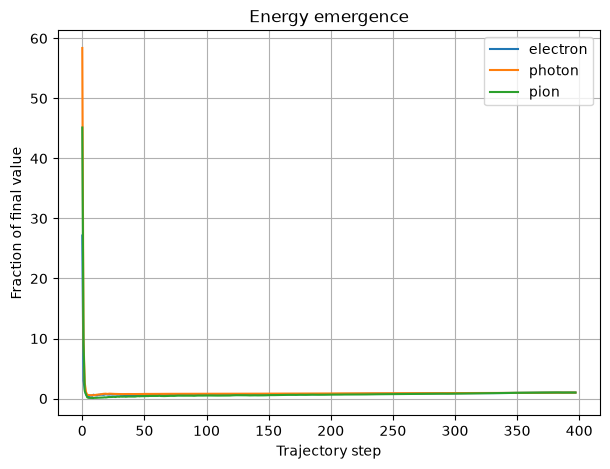

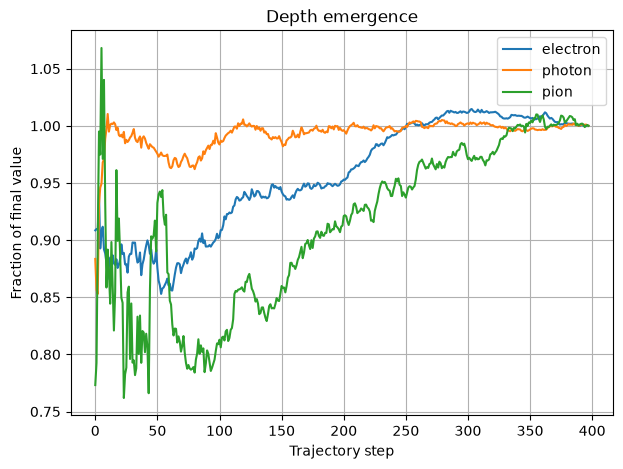

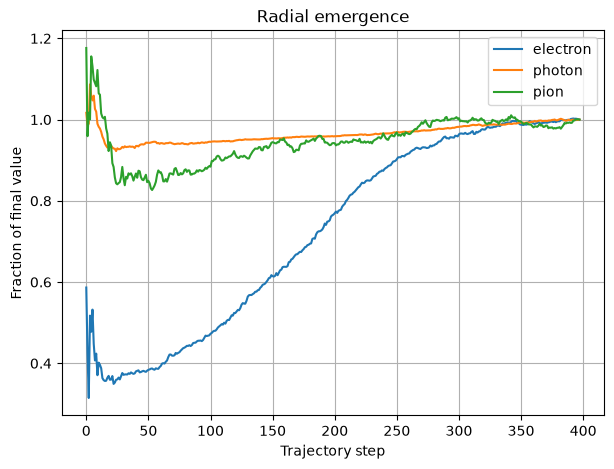

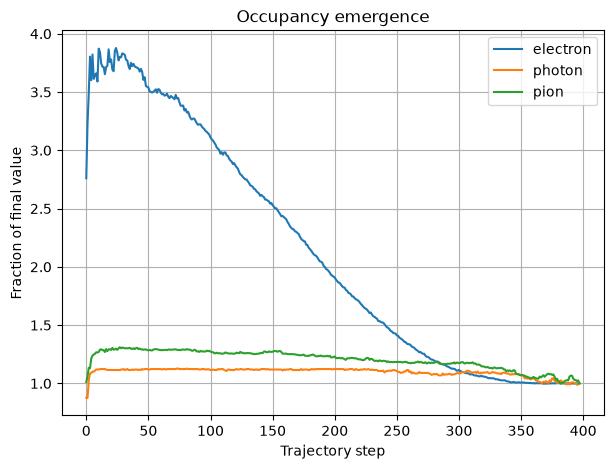

In [29]:
plt.figure(figsize=(7,5))

for particle in ['electron', 'photon', 'pion']:
    vals = np.array(all_curves[particle]['energy'])
    vals = vals / vals[-1]
    plt.plot(vals, label=particle)

plt.xlabel("Trajectory step")
plt.ylabel("Fraction of final value")
plt.title("Energy emergence")
plt.grid()
plt.legend()
plt.show()
plt.figure(figsize=(7,5))

for particle in ['electron', 'photon', 'pion']:
    vals = np.array(all_curves[particle]['depth'])
    vals = vals / vals[-1]
    plt.plot(vals, label=particle)

plt.xlabel("Trajectory step")
plt.ylabel("Fraction of final value")
plt.title("Depth emergence")
plt.grid()
plt.legend()
plt.show()
plt.figure(figsize=(7,5))

for particle in ['electron', 'photon', 'pion']:
    vals = np.array(all_curves[particle]['radial'])
    vals = vals / vals[-1]
    plt.plot(vals, label=particle)

plt.xlabel("Trajectory step")
plt.ylabel("Fraction of final value")
plt.title("Radial emergence")
plt.grid()
plt.legend()
plt.show()
plt.figure(figsize=(7,5))

for particle in ['electron', 'photon', 'pion']:
    vals = np.array(all_curves[particle]['occupancy'])
    vals = vals / vals[-1]
    plt.plot(vals, label=particle)

plt.xlabel("Trajectory step")
plt.ylabel("Fraction of final value")
plt.title("Occupancy emergence")
plt.grid()
plt.legend()
plt.show()

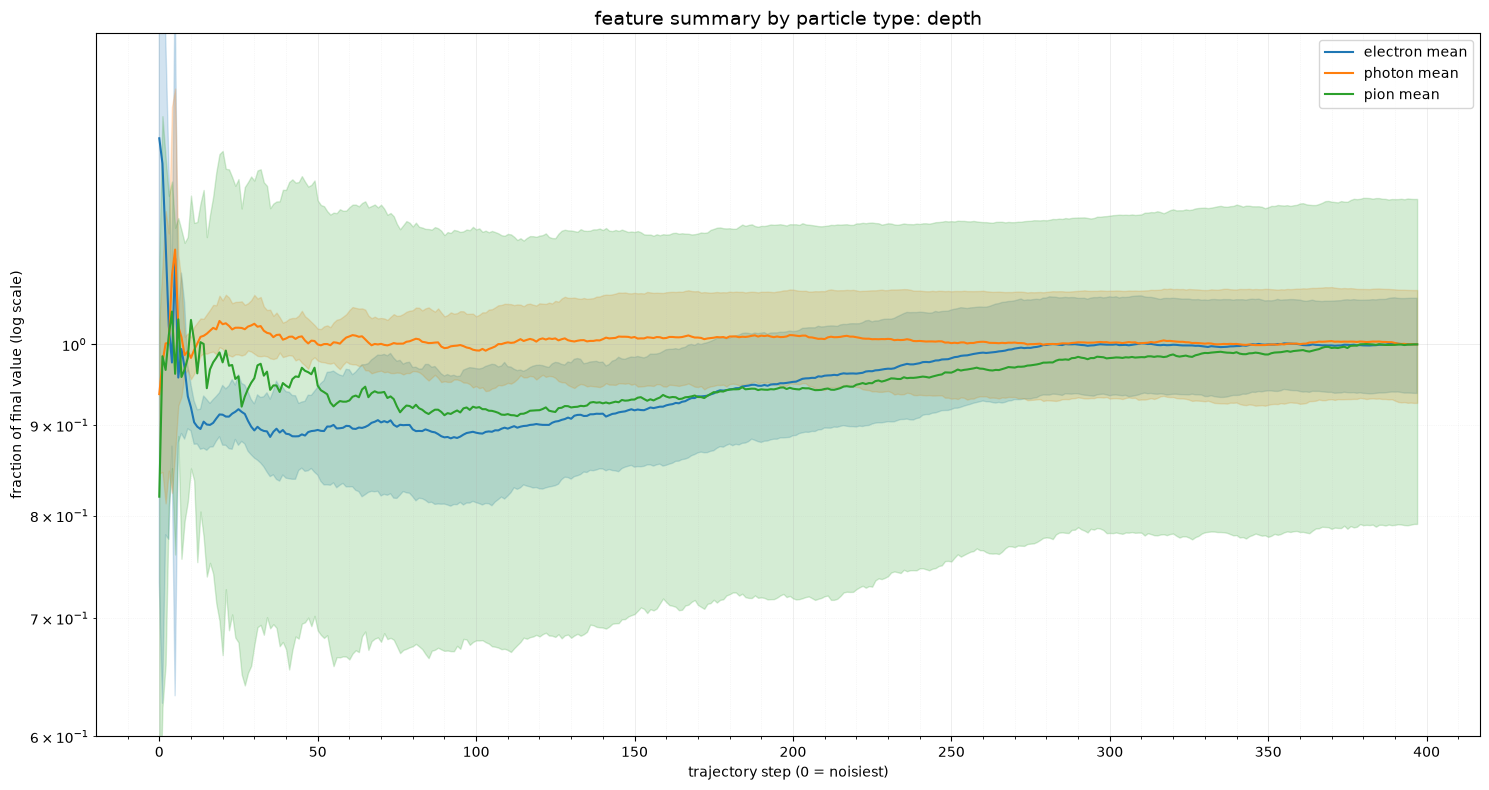

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Choose which physical feature to summarize
feature = 'depth' 

plt.figure(figsize=(15, 8))
colors = {'electron': '#1f77b4', 'photon': '#ff7f0e', 'pion': '#2ca02c'}

for p_type in ['electron', 'photon', 'pion']:
    if p_type in all_stats:
        data = all_stats[p_type][feature]
        steps = np.arange(len(data['mean']))
        
        # REAL Mean Line
        plt.plot(steps, data['mean'], 
                 label=f'{p_type} mean', 
                 color=colors[p_type], 
                 linewidth=1.5)
        
        # REAL Shaded Uncertainty (Standard Deviation)
        plt.fill_between(steps, 
                         data['mean'] - data['std'], 
                         data['mean'] + data['std'], 
                         color=colors[p_type], 
                         alpha=0.2) # Real physical spread

# Formatting to match your reference exactly
plt.yscale('log')
plt.grid(True, which='both', linestyle='-', linewidth=0.5, alpha=0.3)
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', linewidth=0.5, alpha=0.2)

plt.title(f'feature summary by particle type: {feature}', fontsize=14)
plt.xlabel('trajectory step (0 = noisiest)')
plt.ylabel('fraction of final value (log scale)')
plt.legend(loc='upper right')

# Focus the view around the point of emergence (1.0)
plt.ylim(0.6, 1.5) 

plt.tight_layout()
plt.show()